# 3. Models

Module importing

In [6]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Library importing

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_predict, LeaveOneOut
from src.data import load_cache
from src.splits import SPLITS
from src.features import build_feature_table, VARIANCE_FEATURES, DISCHARGE_FEATURES, FULL_FEATURES
from src.models import make_elastic_net
from src.evaluate import results_table, parity_plot, score

Leave-one-out cross validation

In [8]:
cells = load_cache()
tables = {name: build_feature_table(cells, ids) for name, ids in SPLITS.items()}
FEATURE_SETS = {"variance": VARIANCE_FEATURES, "discharge": DISCHARGE_FEATURES, "full": FULL_FEATURES}
y_train = tables["train"]["cycle_life"]

for name, feats in FEATURE_SETS.items():
    oof = cross_val_predict(make_elastic_net(), tables["train"][feats], y_train, cv=LeaveOneOut())
    print(f"{name:10s}", score(y_train, oof))

variance   {'RMSE (cycles)': 126.8, 'MAPE (%)': 16.6}
discharge  {'RMSE (cycles)': 110.9, 'MAPE (%)': 13.1}
full       {'RMSE (cycles)': 111.5, 'MAPE (%)': 12.1}


In [9]:
results, fitted = {}, {}

dummy = DummyRegressor(strategy="mean").fit(tables["train"][FULL_FEATURES], y_train)
results["mean baseline"] = {s: (t["cycle_life"], dummy.predict(t[FULL_FEATURES])) for s, t in tables.items()}

for name, feats in FEATURE_SETS.items():
    model = make_elastic_net().fit(tables["train"][feats], y_train)
    fitted[name] = model
    results[f"elastic net ({name})"] = {s: (t["cycle_life"], model.predict(t[feats])) for s, t in tables.items()}

results_table(results)

RMSE (cycles)                           MAPE (%)  \
split                    primary_test secondary_test  train primary_test   
model                                                                      
elastic net (discharge)         221.2          143.9   78.5         13.6   
elastic net (full)              136.0          261.5   80.1         10.3   
elastic net (variance)          136.6          211.4  121.7         15.4   
mean baseline                   388.8          469.9  322.8         31.9   

                                              
split                   secondary_test train  
model                                         
elastic net (discharge)           10.4  10.4  
elastic net (full)                15.3   9.0  
elastic net (variance)            11.9  16.1  
mean baseline                     31.2  33.5

alpha: 0.00028089769753389014 l1_ratio: 0.5
dq_log_min            -0.445509
qd_max_minus_cycle2   -0.048682
dq_log_skew            0.001463
dq_log_kurt            0.008308
qd_cycle2              0.035429
dq_log_var             0.281486
dtype: float64


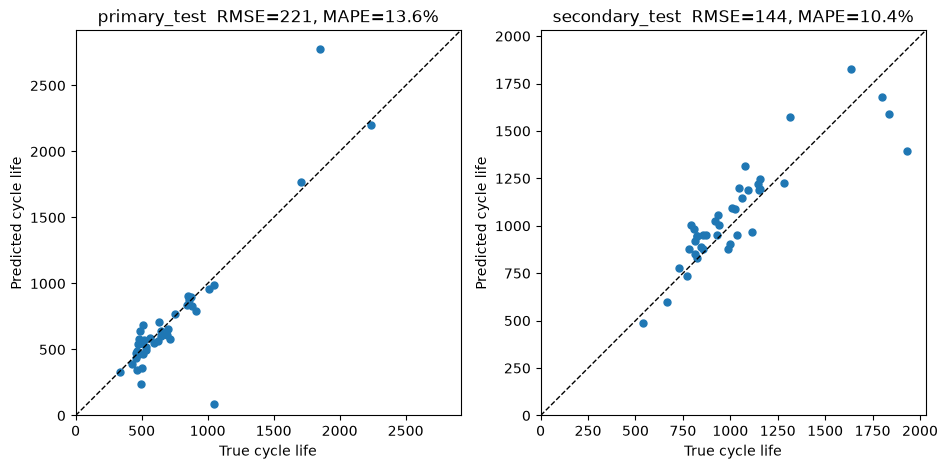

In [10]:
m = fitted["discharge"]
enet = m.regressor_.named_steps["elasticnetcv"]
print("alpha:", enet.alpha_, "l1_ratio:", enet.l1_ratio_)
print(pd.Series(enet.coef_, index=DISCHARGE_FEATURES).sort_values())

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, s in zip(axes, ["primary_test", "secondary_test"]):
    t = tables[s]
    parity_plot(t["cycle_life"], m.predict(t[DISCHARGE_FEATURES]), title=s, ax=ax)